# The Holographic Family: HDE, ADE and RDE

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/salihyesil59/CosmoFit/blob/main/examples/02-models/holographic_family.ipynb)

Three dark-energy models that all start from the same idea and
differ in one choice.

The holographic principle bounds the energy in a region by its
*surface* area rather than its volume, which for a region of size
`L` gives a vacuum density

$$\rho_{\rm DE} = 3c^2 M_p^2 / L^2 .$$

Everything then hangs on what `L` is:

| model | `L` | equation for `E(z)` |
|---|---|---|
| **HDE** | the future event horizon | ODE, integrated |
| **ADE** | the conformal age of the universe | ODE, integrated |
| **RDE** | the Ricci scalar | closed form |

HDE is the original and the most criticized: today's dark-energy
density depends on the *entire future* of the universe. ADE and RDE
are both answers to that objection.

All three are background models with structure the simple
parametrizations don't have — two of them have no closed-form
`E(z)` at all — which makes them a good tour of what a hand-written
`Cosmology` subclass can do.

## Setup

In [ ]:
import sys

# On Colab, install the released package and nothing else.
#
# This used to clone the repository and install it editable,
# which needed a `sys.path` fix afterwards: pip runs in a
# subprocess, so the already-running kernel never saw the .pth
# file it wrote, and `import CosmoFit` could resolve to the bare
# checkout directory instead -- same name, and /content is on
# sys.path. A normal install goes to site-packages, which is
# already there, so all of that goes away.

if "google.colab" in sys.modules:
    !pip install -q cosmofit
else:
    print("Not running in Colab -- assuming CosmoFit is already "
          'installed (pip install cosmofit).')


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from CosmoFit import Fitter
from CosmoFit.cosmology.models import HDE, ADE, RDE, LCDM

plt.rcParams["figure.dpi"] = 110

## 1. What each one adds

One new parameter each, on top of the usual `H0` / `Omega_m`.

In [3]:
for model in (HDE, ADE, RDE):
    print(f"{model.plain_name():>4s}: {sorted(model.EXTRA_PARAMS)}", end="")
    derived = getattr(model, "DERIVED_PARAMS", frozenset())
    print(f"   derived: {sorted(derived) if derived else '-'}")

 HDE: ['c_hde']   derived: -
 ADE: ['n_ade']   derived: ['Omega_m']
 RDE: ['gamma_rde']   derived: -


### ADE has one fewer free parameter than ΛCDM

Its early-time condition, `Omega_DE -> n²a²/4`, fixes the whole
background from `n` alone. So `Omega_m` is not fit — it is
**derived**, and the model declares that in `DERIVED_PARAMS` so a
fitter can warn if you try to sample it.

In [4]:
print(f"{'n':>6s} {'-> Omega_m':>12s}")
for n in (2.4, 2.6, 2.8, 3.0, 3.2):
    m = ADE(ADE.PARAMS_CLASS(H0=70.0, Omega_m=0.3, n_ade=n))
    print(f"{n:6.2f} {m.Omega_m:12.4f}")

print("\n(the Omega_m passed in is ignored -- the model computes its own)")

     n   -> Omega_m
  2.40       0.3588
  2.60       0.3168
  2.80       0.2799
  3.00       0.2477
  3.20       0.2196
(the Omega_m passed in is ignored -- the model computes its own)


## 2. Expansion histories and equations of state

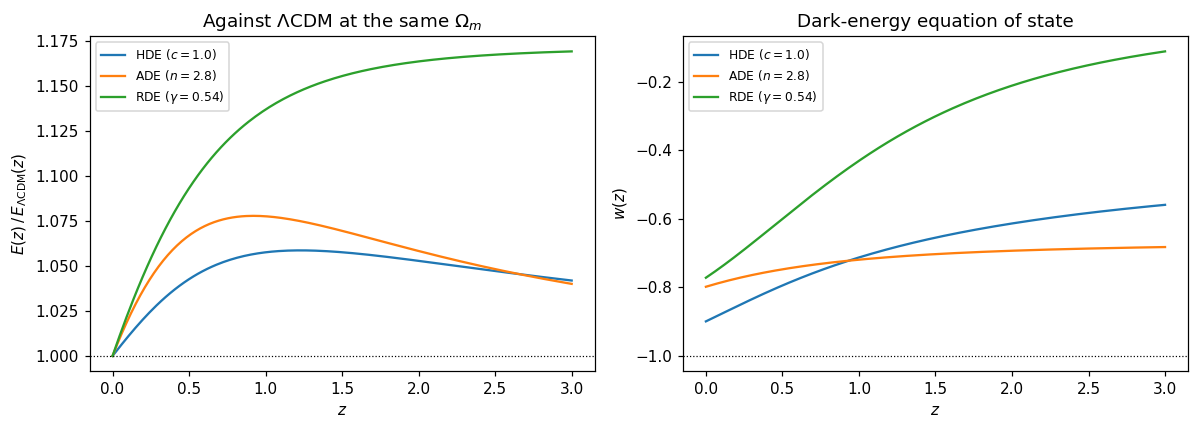

In [5]:
z = np.linspace(0.0, 3.0, 200)
ref = LCDM(LCDM.PARAMS_CLASS(H0=70.0, Omega_m=0.28))

models = {
    "HDE ($c=1.0$)": HDE(HDE.PARAMS_CLASS(H0=70.0, Omega_m=0.28, c_hde=1.0)),
    "ADE ($n=2.8$)": ADE(ADE.PARAMS_CLASS(H0=70.0, Omega_m=0.28, n_ade=2.8)),
    "RDE ($\\gamma=0.54$)": RDE(RDE.PARAMS_CLASS(H0=70.0, Omega_m=0.28,
                                                gamma_rde=0.54)),
}


# Dark-energy equation of state from Omega_de(z) alone:
# conservation of the dark-energy density means
# w = -1 + (1+z) dln(rho_de)/dz / 3. Every model here defines
# Omega_de, so this works for all of them -- HDE and ADE also
# expose w_de directly, and agree with this to the difference.
def effective_w(model, z, h=1e-4):
    z = np.asarray(z, dtype=float)
    rho = model.Omega_de(z)
    drho = (model.Omega_de(z + h) - model.Omega_de(z - h)) / (2 * h)
    return -1.0 + (1.0 + z) * drho / (3.0 * rho)


fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for label, m in models.items():
    axes[0].plot(z, m.E(z) / ref.E(z), label=label)
    axes[1].plot(z, effective_w(m, z), label=label)

axes[0].axhline(1.0, color="k", lw=0.8, ls=":")
axes[0].set_xlabel("$z$")
axes[0].set_ylabel(r"$E(z)\,/\,E_{\Lambda\rm CDM}(z)$")
axes[0].set_title(r"Against $\Lambda$CDM at the same $\Omega_m$")

axes[1].axhline(-1.0, color="k", lw=0.8, ls=":")
axes[1].set_xlabel("$z$")
axes[1].set_ylabel("$w(z)$")
axes[1].set_title("Dark-energy equation of state")

# HDE and ADE carry their own w_de; check the generic route agrees.
for label, m in models.items():
    if hasattr(m, "w_de"):
        assert np.allclose(effective_w(m, z), m.w_de(z), atol=1e-6)

for ax in axes:
    ax.legend(fontsize=8)
fig.tight_layout()

### HDE crosses the phantom divide

`c` controls whether the dark energy ends up quintessence-like
(`c > 1`), ΛCDM-like (`c = 1`) or phantom (`c < 1`) in the far
future — a clean, falsifiable statement, which is why `c ≈ 1` is
the interesting question for this model.

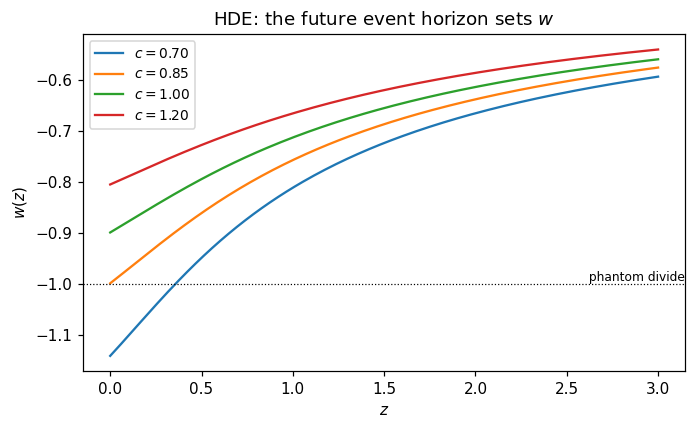

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 4))

for c in (0.7, 0.85, 1.0, 1.2):
    m = HDE(HDE.PARAMS_CLASS(H0=70.0, Omega_m=0.28, c_hde=c))
    ax.plot(z, m.w_de(z), label=f"$c = {c:.2f}$")

ax.axhline(-1.0, color="k", lw=0.8, ls=":")
ax.text(2.6, -1.0, " phantom divide", va="bottom", fontsize=8)
ax.set_xlabel("$z$")
ax.set_ylabel("$w(z)$")
ax.set_title("HDE: the future event horizon sets $w$")
ax.legend(fontsize=9)
fig.tight_layout()

## 3. Against published constraints

The validation configuration is cosmic chronometers + DESI DR2 BAO
+ Pantheon+ — late-time data only, no CMB — matching
[arXiv:2607.09732](https://arxiv.org/abs/2607.09732), which
constrains all three.

In [7]:
DATASETS = ["cc", "desi", "pantheon"]
DR2 = {"desi": {"version": "desi2025"}}

def fit_model(model, extra, initial):
    fit = Fitter(
        model=model,
        datasets=DATASETS,
        dataset_kwargs=DR2,
        free_params=["H0", *extra, "rd"],
        # Omega_m has to be *given* even where it is not fit: ADE
        # derives it from n, but every model still carries the
        # parameter and the fitter needs a value for it.
        initial={"H0": 68.0, "Omega_m": 0.3, "rd": 147.0, **initial},
    )
    best = fit.best_fit(restarts=3, seed=0)
    return fit, best, dict(zip(fit.free_params, best.x))


rde_fit, rde_best, rde_p = fit_model(
    RDE, ["Omega_m", "gamma_rde"], {"Omega_m": 0.25, "gamma_rde": 0.5})

print("RDE")
print(f"  gamma    = {rde_p['gamma_rde']:.4f}    published 0.53 - 0.55")
print(f"  Omega_m0 = {rde_p['Omega_m']:.4f}    published 0.215 - 0.219")
print(f"  chi2     = {rde_best.fun:.3f}")

RDE
  gamma    = 0.5385    published 0.53 - 0.55
  Omega_m0 = 0.2179    published 0.215 - 0.219
  chi2     = 1477.891


In [8]:
hde_fit, hde_best, hde_p = fit_model(
    HDE, ["Omega_m", "c_hde"], {"Omega_m": 0.28, "c_hde": 0.9})

print("HDE")
print(f"  c        = {hde_p['c_hde']:.4f}    published ~ 1")
print(f"  Omega_m0 = {hde_p['Omega_m']:.4f}    published 0.270 - 0.272")
print(f"  H0       = {hde_p['H0']:.4f}    published 67.3 - 68.0")
print(f"  chi2     = {hde_best.fun:.3f}")

HDE
  c        = 0.9987    published ~ 1
  Omega_m0 = 0.2720    published 0.270 - 0.272
  H0       = 67.8888    published 67.3 - 68.0
  chi2     = 1479.273


In [9]:
ade_fit, ade_best, ade_p = fit_model(ADE, ["n_ade"], {"n_ade": 2.8})
ade_cosmo = ADE(ADE.PARAMS_CLASS(H0=ade_p["H0"], Omega_m=0.3,
                                 n_ade=ade_p["n_ade"]))

print("ADE")
print(f"  n              = {ade_p['n_ade']:.4f}    published 2.78 - 2.81")
print(f"  -> Omega_m0    = {ade_cosmo.Omega_m:.4f}   (derived, not fit)")
print(f"  chi2           = {ade_best.fun:.3f}")
print("\nThe n-to-Omega_m mapping is exact model physics, and it")
print("reproduces the published pair:")
check = ADE(ADE.PARAMS_CLASS(H0=68.0, Omega_m=0.3, n_ade=2.80))
print(f"  n = 2.80  ->  Omega_m = {check.Omega_m:.4f}  "
      f"(their quoted pair)")

ADE
  n              = 2.8435    published 2.78 - 2.81
  -> Omega_m0    = 0.2725   (derived, not fit)
  chi2           = 1487.258
The n-to-Omega_m mapping is exact model physics, and it
reproduces the published pair:
  n = 2.80  ->  Omega_m = 0.2799  (their quoted pair)


RDE lands inside both published intervals. HDE reproduces `c ≈ 1`
and the quoted `Omega_m0`/`H0`. ADE's fitted `n` is about 2% above
the published range — and the honest reading is that the *model* is
right and the *fit* differs, because the `n → Omega_m` mapping,
which is pure model physics with no data in it, reproduces their
pair exactly. The residual is in where these particular datasets
pull `Omega_m`.

### Where HDE's `c` gets pulled from

That paper also reports a split between probes, which falls out
here without being used as an input.

In [10]:
for label, datasets in [("supernovae only", ["pantheon"]),
                       ("BAO only", ["desi"]),
                       ("combined", DATASETS)]:
    free = ["H0", "Omega_m", "c_hde"]
    initial = {"H0": 68.0, "Omega_m": 0.28, "c_hde": 0.9}
    if "desi" in datasets:
        free.append("rd"); initial["rd"] = 147.0

    f = Fitter(model=HDE, datasets=datasets, dataset_kwargs=DR2,
               free_params=free, initial=initial)
    b = f.best_fit(restarts=3, seed=0)
    c = dict(zip(f.free_params, b.x))["c_hde"]
    print(f"  {label:16s}  c = {c:.3f}")

print("\nSupernovae pull c above unity, BAO pushes it below --")
print("the published split, reproduced.")

  supernovae only   c = 1.183


  BAO only          c = 0.930


  combined          c = 0.999
Supernovae pull c above unity, BAO pushes it below --
the published split, reproduced.


## 4. A posterior for HDE

`c = 1` is the question this model poses, so the width of `c` is
what matters, not just its best fit.

In [11]:
hde_fit.run_mcmc(nwalkers=32, nsteps=3000, burnin=600, seed=0, progress=True)
print(hde_fit.result)

  0%|          | 0/3000 [00:00<?, ?it/s]


  0%|          | 1/3000 [00:00<11:19,  4.41it/s]


  0%|          | 2/3000 [00:00<11:23,  4.39it/s]


  0%|          | 3/3000 [00:00<11:40,  4.28it/s]


  0%|          | 4/3000 [00:00<11:54,  4.19it/s]


...

100%|█████████▉| 2999/3000 [12:33<00:00,  2.32it/s]


100%|██████████| 3000/3000 [12:33<00:00,  2.32it/s]


100%|██████████| 3000/3000 [12:33<00:00,  3.98it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 48;
tau: [50.23765095 40.60608055 44.37737465 48.57222074]


FitResult(model=HDE, datasets=['cc', 'desi', 'pantheon'], free_params=['H0', 'Omega_m', 'c_hde', 'rd'])
  BestFitResult(H0=67.8888, Omega_m=0.271951, c_hde=0.998724, rd=146.912, chi2=1479.2726, AIC=1487.27, BIC=1508.95)
  MCMCResult(32 walkers x 3000 steps, burnin=600, NOT converged, acceptance=0.56)
  H0 = 68.2247 (+3.1/-3.1)
  Omega_m = 0.271594 (+0.0083/-0.0085)
  c_hde = 1.00968 (+0.085/-0.077)
  rd = 146.084 (+6.9/-6.3)


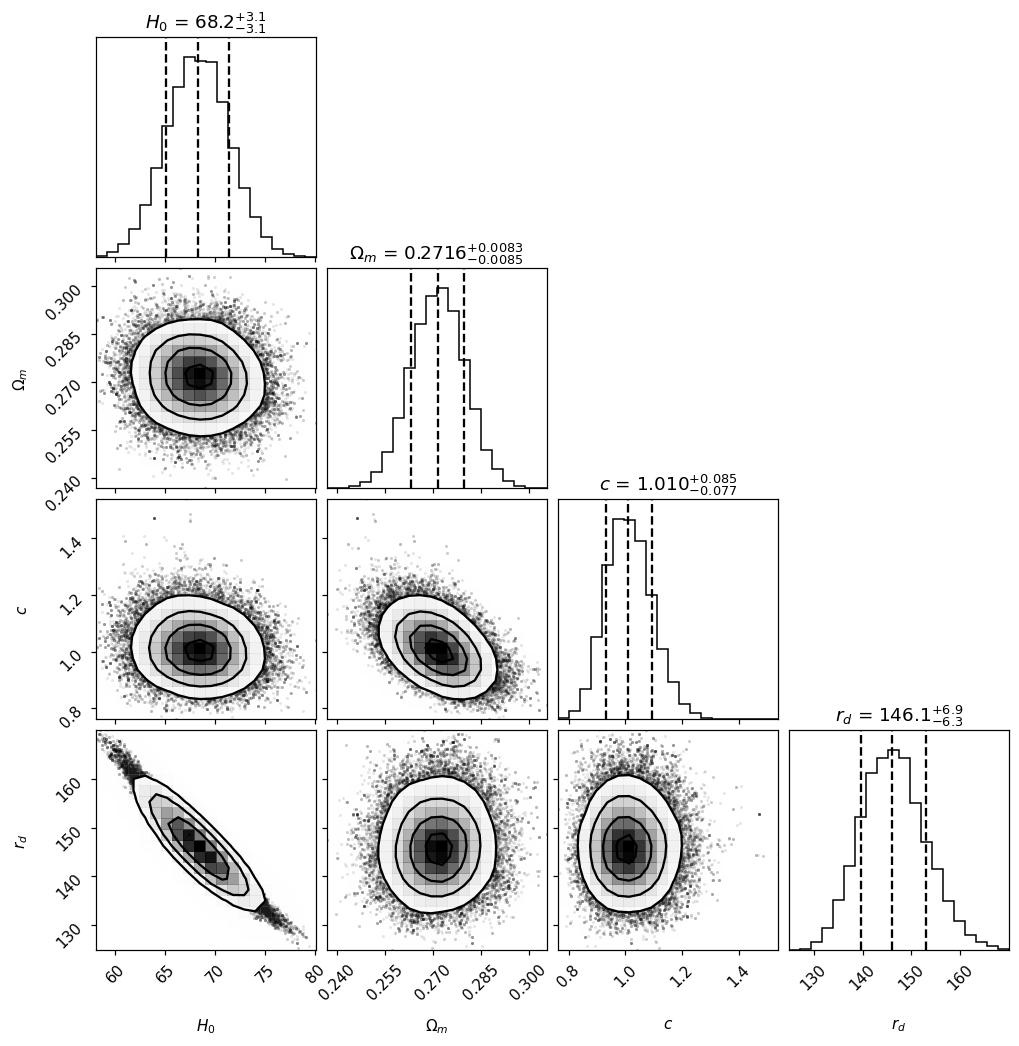

In [12]:
hde_fit.plots.corner();

In [13]:
summary = hde_fit.summary()["c_hde"]
low = summary["median"] - summary["minus"]
high = summary["median"] + summary["plus"]
print(f"c = {summary['median']:.3f}  -{summary['minus']:.3f} +{summary['plus']:.3f}")
print(f"68% interval: {low:.3f} to {high:.3f}")
print(f"\nconsistent with c = 1: {low <= 1.0 <= high}")

c = 1.010  -0.077 +0.085
68% interval: 0.933 to 1.095
consistent with c = 1: True


## 5. How they compare on the same data

In [14]:
from CosmoFit.stats.model_comparison import aic, bic

lcdm_fit = Fitter(
    model=LCDM, datasets=DATASETS, dataset_kwargs=DR2,
    free_params=["H0", "Omega_m", "rd"],
    initial={"H0": 68.0, "Omega_m": 0.3, "rd": 147.0},
)
lcdm_best = lcdm_fit.best_fit(restarts=3, seed=0)

n_data = lcdm_fit.n_data
rows = [
    ("LCDM", lcdm_best.fun, len(lcdm_fit.free_params)),
    ("HDE", hde_best.fun, len(hde_fit.free_params)),
    ("ADE", ade_best.fun, len(ade_fit.free_params)),
    ("RDE", rde_best.fun, len(rde_fit.free_params)),
]

print(f"{'model':>6s} {'chi2':>9s} {'k':>3s} {'AIC':>9s} {'BIC':>9s} "
      f"{'dAIC':>7s}")
base_aic = aic(lcdm_best.fun, len(lcdm_fit.free_params))
for name, chi2, k in rows:
    print(f"{name:>6s} {chi2:9.3f} {k:3d} {aic(chi2, k):9.3f} "
          f"{bic(chi2, k, n_data):9.3f} {aic(chi2, k) - base_aic:+7.2f}")
print(f"\n(dAIC > 0 means worse than LCDM; {n_data} data points)")

 model      chi2   k       AIC       BIC    dAIC
  LCDM  1483.150   3  1489.150  1505.410   +0.00
   HDE  1479.273   4  1487.273  1508.952   -1.88
   ADE  1487.258   3  1493.258  1509.518   +4.11
   RDE  1477.891   4  1485.891  1507.571   -3.26
(dAIC > 0 means worse than LCDM; 1669 data points)


## Notes on getting these right

Two of these models were first written with bugs that the *fit*
would never have shown, and only a physics check caught:

- **HDE's `Omega_de(z)`** returned the density *parameter*
  `rho_DE/rho_crit(z)` where the rest of this library means
  `rho_DE/rho_crit(0)`. The two agree at `z = 0`, which is why it
  passed inspection, and differ by a factor 0.59 at `z = 0.5`.
- **RDE's `Omega_de(z)`** returned the second term of `E²` — but
  the Ricci density carries a matter-like piece, so the `(1+z)³`
  coefficient is `A = 2Ω_m/(2-γ) > Ω_m`. Reading the two terms as
  "matter" and "dark energy" misplaces about a third of the matter
  density.
- **ADE** was first integrated *backwards* from today with `Omega_m`
  free, which is silently a different model: its early-time limit
  came out at 0.44 instead of the required 1.96.

The lesson each time was the same — `E(z)` looked fine throughout.
Checking a model against its own defining relation, not against the
data, is what found them.

## Where to go next

- [`model_zoo_comparison.ipynb`](model_zoo_comparison.ipynb) — the
  simpler dark-energy parametrizations head to head.
- [`modified_gravity_growth.ipynb`](modified_gravity_growth.ipynb) —
  models that change gravity rather than the dark-energy fluid.
- [`../03-building-models/models_from_an_action.ipynb`](../03-building-models/models_from_an_action.ipynb)
  — deriving a model's `E(z)` from its action instead of writing it.